# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

import sys
from pathlib import Path

# Add src/ to path (once, so imports work)
sys.path.append(str(Path().resolve().parent / "src"))
# 
# Enable autoreload for Jupyter notebooks
%load_ext autoreload
%autoreload 2

from paths import DATA_DATASETS
from helper_functions import get_master_dataframe
import feature_construction as fc

Failed to read module file 'C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\functools.py' for module 'functools': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\JuliusAdmin\Documents\GitHub\Marketing-Analytics\.venv\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\JuliusAdmin\AppData\Local\Programs\Python\Python312\Lib\importlib\__init__.py", line 90, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1387, in _gcd_import
  File "<frozen importlib._bootstrap>", line 

In [2]:
# Get master dataframe - constructed of transactions, outfits, and outfit_clusters
master = get_master_dataframe()


test_customers = pd.read_csv(DATA_DATASETS / "test_customers.csv", sep=";")
baseline_pred = pd.read_csv(DATA_DATASETS / "pred.csv")

Master shape: (60897, 11)
   customer.id                                outfit.id rentalPeriod.start  \
0         3448  outfit.5c081909537b42239e465d2d615c705f         2023-03-26   
1         2924  outfit.c34969dd8b334064aa90bfb60c8ec308         2023-03-27   

  rentalPeriod.end  cluster         cluster_name  pricePerWeek  pricePerMonth  \
0       2023-04-25      3.0  Sweaters & Knitwear         750.0         1500.0   
1       2023-04-26      7.0      Jackets & Coats         990.0         1980.0   

   retailPrice  duration_days  revenue  
0       2500.0             30   1500.0  
1       3900.0             30   1980.0  


# CLV Model

### Feature Engineering

#### RFM Features
| Feature | Description |
|---|---|
| `recency` | Days since last rental before cutoff — low recency = recently active customer |
| `frequency` | Total number of rentals in training period |
| `monetary` | Total revenue generated across all rentals |
| `avg_revenue` | Average revenue per rental transaction |
| `std_revenue` | Variability in spending — high std = inconsistent renter |
| `weighted_rev` | Revenue weighted by exponential time decay (λ=365 days) — recent transactions count more |
| `weighted_frequency` | Frequency weighted by exponential time decay (λ=365 days) — recent rentals count more heavily than older ones |
| `avg_duration` | Average duration of a rental in days — indicates typical engagement length per transaction |
| `recency_x_monetary` | Interaction term (recency * monetary) — captures the combined risk/value profile of historically high spenders who are currently inactive |
| `recency_x_frequency` | Interaction term (recency * frequency) — distinguishes between a one-time renter who left vs. a frequent renter who suddenly stopped |
| `monetary_x_frequency` | Interaction term (monetary * frequency) — amplifies the signal of high-value, high-engagement "whale" customers |

#### Temporal Features
| Feature | Description |
|---|---|
| `tenure_days` | Days between first and last rental — captures customer lifetime so far |
| `avg_days_between_rentals` | Mean inter-rental interval — proxy for rental cadence |
| `recency_ratio` | Recency divided by avg_days_between_rentals — values above 1 indicate the customer is overdue relative to their personal rhythm; more informative than raw recency alone |
| `revenue_trend` | Revenue difference between second and first half of rental history — positive = growing customer, negative = declining customer |
| `pct_weekly_rentals` | Share of rentals with duration ≤7 days — distinguishes event-driven one-time renters from habit-based monthly renters |
| `active_months` | Number of distinct calendar months with at least one rental |
| `n_spring/summer/autumn/winter` | Rental count per season — captures seasonal preferences |
| `revenue_per_day` | Total monetary value divided by tenure days — measures customer "velocity" or daily monetary generation rate |
| `rentals_per_day` | Total frequency divided by tenure days — measures how densely packed the customer's rental cadence is |

#### Product Cluster Affinity Features
| Feature | Description |
|---|---|
| `cluster_affinity_0..7` | Share of total spending allocated to each of the 8 product clusters — captures style preference profile per customer |
| `n_clusters_rented` | Number of distinct product clusters ever rented — operationalizes Hypothesis 3: customers who engage across multiple style categories show significantly higher loyalty than those concentrating on a single cluster |
| `style_entropy` | Shannon entropy across cluster affinity shares — continuous measure of style diversity; higher entropy = broader engagement across categories |

#### Price Segment Features
| Feature | Description |
|---|---|
| `avg_retail_price` | Average retail price of rented outfits — proxy for price sensitivity |
| `max_retail_price` | Highest retail price item ever rented — captures willingness to pay |
| `avg_price_per_week` | Average weekly rental rate across all transactions |

#### Use just data after clear break

In [3]:
# Fold structure
TIMEFRAME_START  = pd.Timestamp("2020-04-01")
TRAIN_CUTOFF     = pd.Timestamp("2021-09-06")  # features end here for training
LABEL_END        = pd.Timestamp("2022-09-06")  # labels end here for training
FINAL_CUTOFF     = pd.Timestamp("2023-09-06")  # features end here for submission

X_train, X_test, y_train, y_test, id_train, id_test = fc.generate_train_test_splits(df=master, timeframe_start=TIMEFRAME_START, train_cutoff=TRAIN_CUTOFF, label_end=LABEL_END, final_cutoff=FINAL_CUTOFF)

# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1
)

# Training fold
# Features: April 2020 → Sept 2021
# Labels:   Sept 2021 → Sept 2022  (genuinely future, never seen during training)
lgbm_model.fit(X_train, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train)), a_min=0, a_max=None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")

# Test fold
# Features: Sept 2021 → Sept 2022 (former training labels, now features)
# Labels:   Sept 2022 → Sept 2023
test_predictions = np.clip(np.array(lgbm_model.predict(X_test)), a_min=0, a_max=None)
test_mae = mean_absolute_error(y_test, test_predictions)
print(f"MAE on test fold: {test_mae:.2f} NOK")

MAE on training fold: 3131.94 NOK
MAE on test fold: 12674.22 NOK


In [4]:
# Naive baseline comparison
# Check if the model is actually useful
mean_pred = np.full_like(y_test, y_train.mean(), dtype=float)
zero_pred  = np.zeros_like(y_test)

print(f"MAE (predict zero for everyone): {mean_absolute_error(y_test, zero_pred):.2f} NOK")
print(f"MAE (predict mean for everyone): {mean_absolute_error(y_test, mean_pred):.2f} NOK")
print(f"MAE (LightGBM):                  {test_mae:.2f} NOK")

MAE (predict zero for everyone): 13389.62 NOK
MAE (predict mean for everyone): 21073.53 NOK
MAE (LightGBM):                  12674.22 NOK


In [5]:
# Where is the error coming from?
residuals = pd.DataFrame({
    "customer.id": id_test.values.ravel(),
    "actual":      y_test.values.ravel(),
    "predicted":   test_predictions.ravel(),
})

residuals["error"] = np.abs(residuals["actual"] - residuals["predicted"])

# Error by actual revenue bucket
residuals["bucket"] = pd.cut(
    residuals["actual"],
    bins   = [0, 1, 1000, 5000, 20000, 999999],
    labels = ["zero (churned)", "1–1k NOK", "1k–5k NOK", "5k-20k NOK", "20k+ NOK"],
    include_lowest=True)

print("=== MAE by actual revenue bucket ===")
print(residuals.groupby("bucket", observed=True).agg(
    n_customers = ("actual", "count"),
    mae         = ("error", "mean"),
    avg_actual  = ("actual", "mean"),
    avg_pred    = ("predicted", "mean")
).round(2))

=== MAE by actual revenue bucket ===
                n_customers       mae  avg_actual  avg_pred
bucket                                                     
zero (churned)         1088   6376.80        0.00   6376.80
1k–5k NOK                74  21600.45     2990.24  23847.88
5k-20k NOK              144  21002.32    12008.77  28717.30
20k+ NOK                356  26696.17    57030.92  44716.80


In [6]:
# Check feature importance
importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 features:")
print(importance.head(15).to_string(index=False))

print("Bottom 10 features (candidates to drop):")
print(importance.tail(10).to_string(index=False))

Top 15 features:
           feature  importance
     revenue_trend         374
           recency         343
weighted_frequency         285
       std_revenue         278
      avg_duration         273
       avg_revenue         243
     style_entropy         234
  avg_retail_price         233
   revenue_per_day         223
      weighted_rev         208
     recency_ratio         190
cluster_affinity_2         180
avg_price_per_week         159
cluster_affinity_1         158
cluster_affinity_3         154
Bottom 10 features (candidates to drop):
             feature  importance
            n_winter          92
monetary_x_frequency          88
            monetary          73
  cluster_affinity_0          57
  cluster_affinity_4          48
           frequency          42
  pct_weekly_rentals          33
   n_clusters_rented          20
       active_months          14
     rentals_per_day          13


#### Use all of the data

In [7]:
# Fold structure
# TIMEFRAME_START  = pd.Timestamp("2017-04-01")
TRAIN_CUTOFF     = pd.Timestamp("2021-09-06")  # features end here for training
LABEL_END        = pd.Timestamp("2022-09-06")  # labels end here for training
FINAL_CUTOFF     = pd.Timestamp("2023-09-06")  # features end here for submission

X_train, X_test, y_train, y_test, id_train, id_test = fc.generate_train_test_splits(df=master, train_cutoff=TRAIN_CUTOFF, label_end=LABEL_END, final_cutoff=FINAL_CUTOFF)

# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1
)

# Training fold
# Features: April 2017 → Sept 2021
# Labels:   Sept 2021 → Sept 2022  (genuinely future, never seen during training)
lgbm_model.fit(X_train, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train)), a_min=0, a_max=None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")

# Test fold
# Features: Sept 2021 → Sept 2022 (former training labels, now features)
# Labels:   Sept 2022 → Sept 2023
test_predictions = np.clip(np.array(lgbm_model.predict(X_test)), a_min=0, a_max=None)
test_mae = mean_absolute_error(y_test, test_predictions)
print(f"MAE on test fold: {test_mae:.2f} NOK")

MAE on training fold: 901.30 NOK
MAE on test fold: 3296.43 NOK


With this model we can already beat the baseline.

In [8]:
# Where is the error coming from?
residuals = pd.DataFrame({
    "customer.id": id_test.values.ravel(),
    "actual":      y_test.values.ravel(),
    "predicted":   test_predictions.ravel(),
})

residuals["error"] = np.abs(residuals["actual"] - residuals["predicted"])

# Error by actual revenue bucket
residuals["bucket"] = pd.cut(
    residuals["actual"],
    bins   = [0, 1, 1000, 5000, 20000, 999999],
    labels = ["zero (churned)", "1–1k NOK", "1k–5k NOK", "5k-20k NOK", "20k+ NOK"],
    include_lowest=True)

print("MAE by actual revenue bucket:")
print(residuals.groupby("bucket", observed=True).agg(
    n_customers = ("actual", "count"),
    mae         = ("error", "mean"),
    avg_actual  = ("actual", "mean"),
    avg_pred    = ("predicted", "mean")
).round(2))

MAE by actual revenue bucket:
                n_customers       mae  avg_actual  avg_pred
bucket                                                     
zero (churned)         6193   1150.30        0.00   1150.30
1k–5k NOK                84  19534.45     2951.35  21214.34
5k-20k NOK              164  20496.59    11888.91  25444.03
20k+ NOK                368  28041.35    56699.01  42521.45


In [9]:
# Feature importance
importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Top 15 features:")
print(importance.head(15).to_string(index=False))

print("Bottom 10 features (candidates to drop):")
print(importance.tail(10).to_string(index=False))

Top 15 features:
            feature  importance
 cluster_affinity_3         433
            recency         406
        std_revenue         387
      recency_ratio         291
      revenue_trend         280
       weighted_rev         272
      style_entropy         265
       avg_duration         262
        avg_revenue         239
recency_x_frequency         212
 cluster_affinity_1         206
 recency_x_monetary         190
 weighted_frequency         190
        tenure_days         189
           n_summer         187
Bottom 10 features (candidates to drop):
                 feature  importance
                n_autumn         106
      avg_price_per_week          97
    monetary_x_frequency          95
avg_days_between_rentals          77
      pct_weekly_rentals          59
           active_months          50
      cluster_affinity_0          34
         rentals_per_day          27
       n_clusters_rented          18
      cluster_affinity_4          15


#### Use of all data & log transforming revenue

In [10]:
# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1
)

y_train_log = np.log1p(y_train)  # log(1 + y) so 0 stays 0

lgbm_model.fit(X_train, y_train_log)

# Back transformation for MAE in NOK
predictions_log = np.array(lgbm_model.predict(X_test))
predictions_nok = np.expm1(predictions_log)  # exp(x) - 1
predictions_nok = np.clip(predictions_nok, 0, None)

mae = mean_absolute_error(y_test, predictions_nok)
print(f"MAE on test fold: {mae:.2f} NOK")

MAE on test fold: 3327.57 NOK


#### Use of all data and Tweedie regression with log-link

In [11]:
# Fit and evaluate
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

# Train fold
lgbm_model.fit(X_train, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train)), 0, None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")


# Test fold
test_predictions = np.clip(np.array(lgbm_model.predict(X_test)), 0, None)

test_mae = mean_absolute_error(y_test, test_predictions)
print(f"MAE on test fold: {test_mae:.2f} NOK")

MAE on training fold: 323.97 NOK
MAE on test fold: 2595.25 NOK


In [12]:
importance = pd.DataFrame({
    "feature":    X_train.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance)

                     feature  importance
0                    recency        1329
6               weighted_rev         859
32          avg_retail_price         850
7         recency_x_monetary         718
5               avg_duration         646
3                avg_revenue         515
35        weighted_frequency         490
12             recency_ratio         474
34        avg_price_per_week         470
33          max_retail_price         434
8        recency_x_frequency         420
2                   monetary         386
13           revenue_per_day         379
4                std_revenue         375
20             revenue_trend         304
24        cluster_affinity_2         272
10               tenure_days         243
11  avg_days_between_rentals         206
29        cluster_affinity_7         199
31             style_entropy         191
28        cluster_affinity_6         187
16                  n_summer         186
23        cluster_affinity_1         182
22        cluste

#### Check correlation between features

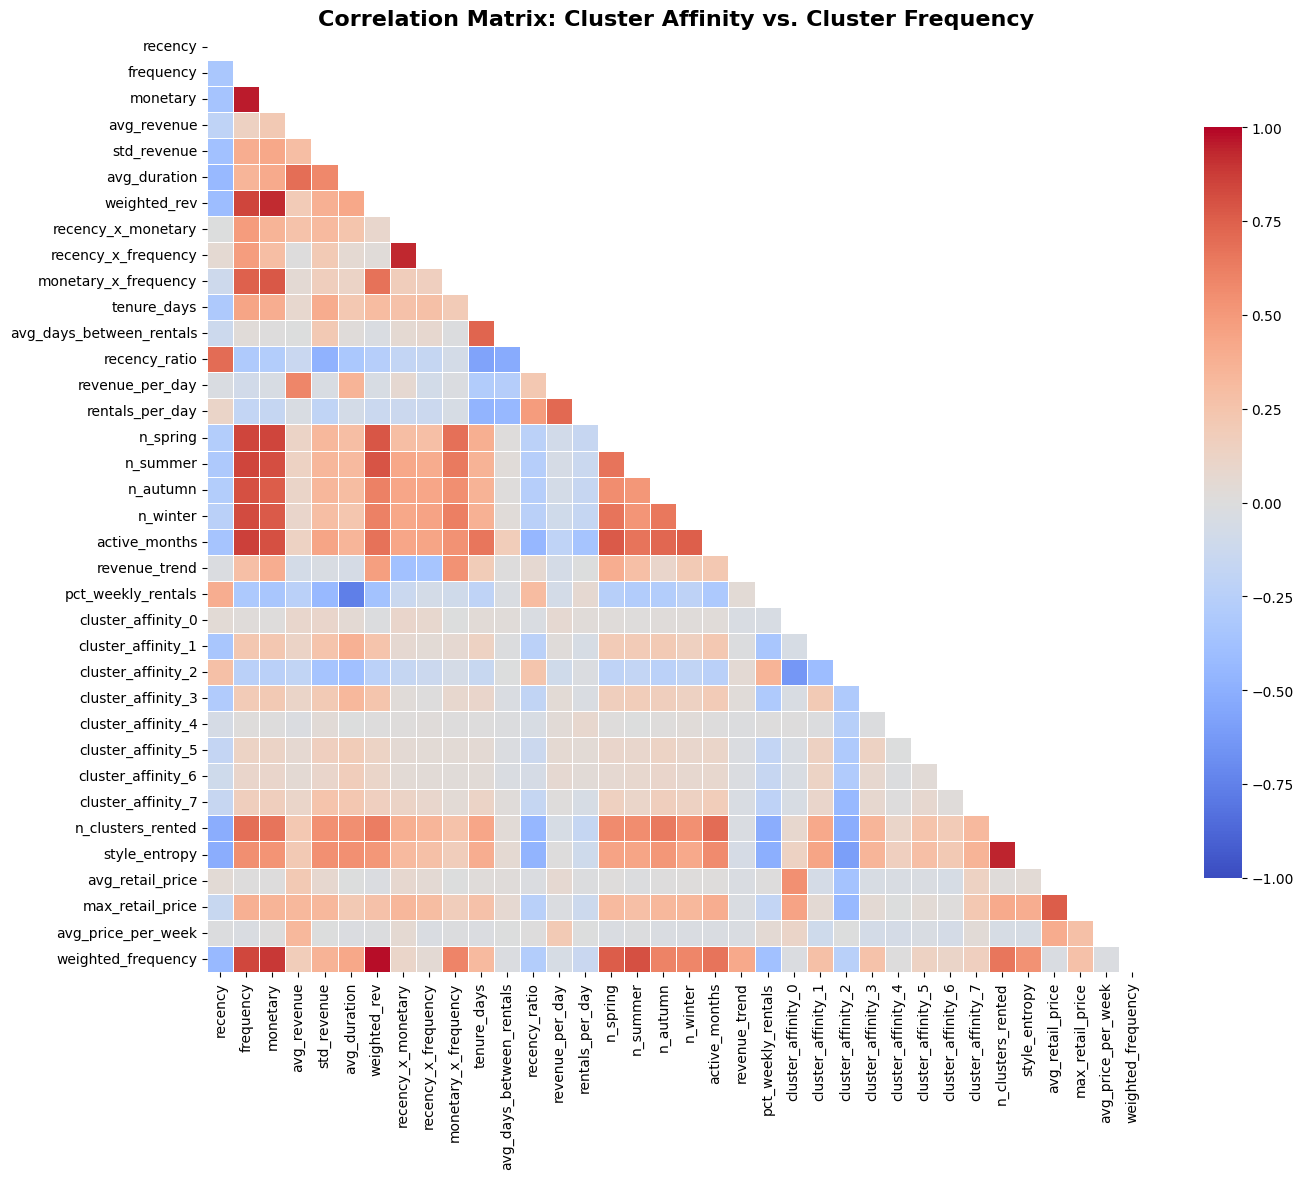

In [13]:
# Calculate the correlation matrix
corr_matrix = X_train.corr()

# Create a mask to hide the upper triangle (for a cleaner look)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))


plt.figure(figsize=(14, 12))
plt.title("Correlation Matrix: Cluster Affinity vs. Cluster Frequency", fontsize=16, fontweight='bold')

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', # Blue for negative correlation, Red for positive
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75},
    annot=False
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
# Calculate the absolute correlation matrix
corr_matrix = X_train.corr().abs()

# Extract the upper triangle to avoid duplicates (A vs B and B vs A)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Unstack the matrix to create a Series of all feature pairs
pairs = upper.unstack().dropna()

# Filter for highly correlated pairs based on your threshold
threshold = 0.85 
highly_correlated_pairs = pairs[pairs > threshold].sort_values(ascending=False)

# Convert to a clean DataFrame for easy viewing
correlated_df = highly_correlated_pairs.reset_index()
correlated_df.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Print the results
print(f"--- Feature pairs with correlation > {threshold} ---")
print(correlated_df.to_string(index=False))

--- Feature pairs with correlation > 0.85 ---
          Feature 1          Feature 2  Correlation
 weighted_frequency       weighted_rev     0.979524
           monetary          frequency     0.958432
      style_entropy  n_clusters_rented     0.942915
recency_x_frequency recency_x_monetary     0.929909
       weighted_rev           monetary     0.929362
 weighted_frequency           monetary     0.887029
      active_months          frequency     0.865420
           n_summer          frequency     0.851234


Lets remove cluster_freq_ from our feature list.

### Feature ablation test

In [15]:
full_features = X_train.columns.tolist()

lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

lgbm_model.fit(X_train, y_train)

baseline_pred = lgbm_model.predict(X_test)
baseline_pred = np.clip(np.array(baseline_pred), 0, None)

baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Baseline MAE:", baseline_mae)

Baseline MAE: 2595.248428944326


In [16]:
# Define feature groups for ablation and interpretability
feature_groups = {
    "rfm_core": ["recency", "frequency", "monetary"],
    
    "revenue_stats": ["avg_revenue", "std_revenue", "weighted_rev"],
    
    "time_features": ["recency_ratio", "avg_days_between_rentals", "tenure_days"],
    
    "velocity": ["revenue_per_day", "rentals_per_day"],
    
    "interactions": ["recency_x_monetary", "recency_x_frequency", "monetary_x_frequency"],
    
    "price": ["avg_retail_price", "max_retail_price", "avg_price_per_week"],
    
    "seasonality": ["n_spring", "n_summer", "n_autumn", "n_winter", "active_months"],
    
    "clusters_revenue": [c for c in full_features if "cluster_affinity_" in c],
    
    "clusters_affinity": [c for c in full_features if "cluster_affinity_" in c],
    
    "behavior": ["pct_weekly_rentals", "revenue_trend", "avg_duration"]
}

In [17]:
results = []

for group_name, cols in feature_groups.items():

    remaining_features = [f for f in full_features if f not in cols]

    
    X_train_sub = X_train[remaining_features]
    X_test_sub  = X_test[remaining_features]
    
    lgbm_model = lgb.LGBMRegressor(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 6,
        min_child_samples = 20,
        subsample         = 0.8,
        random_state      = 42,
        verbose           = -1,

        objective="tweedie",
        tweedie_variance_power=1.3
    )
    lgbm_model.fit(X_train_sub, y_train)
    
    pred = lgbm_model.predict(X_test_sub)
    pred = np.clip(np.array(pred), 0, None)
    
    mae = mean_absolute_error(y_test, pred)
    
    results.append({
        "group_removed": group_name,
        "mae": mae,
        "delta_vs_baseline": mae - baseline_mae
    })


In [18]:
results_df = pd.DataFrame(results).sort_values("delta_vs_baseline")
results_df

,group_removed,mae,delta_vs_baseline
4,interactions,2582.054155,-13.194274
9,behavior,2602.491219,7.242790
5,price,2609.625383,14.376954
0,rfm_core,2633.079877,37.831448
2,time_features,2634.024866,38.776437
3,velocity,2638.045014,42.796585
8,clusters_affinity,2638.891042,43.642613
7,clusters_revenue,2638.891042,43.642613
1,revenue_stats,2651.908620,56.660191
6,seasonality,2663.699929,68.451500


In [19]:
fine_groups = {
    # interactions
    "recency_x_monetary": ["recency_x_monetary"],
    "recency_x_frequency": ["recency_x_frequency"],
    "monetary_x_frequency": ["monetary_x_frequency"],

    # price
    "avg_retail_price": ["avg_retail_price"],
    "max_retail_price": ["max_retail_price"],
    "avg_price_per_week": ["avg_price_per_week"],

    # behavior
    "pct_weekly_rentals": ["pct_weekly_rentals"],
    "revenue_trend": ["revenue_trend"],
    "avg_duration": ["avg_duration"],
}

In [20]:
results = []

for col in [c for c in full_features if "cluster_affinity_" in c]:
    fine_groups[col] = [col]

for group_name, cols in fine_groups.items():

    remaining_features = [f for f in full_features if f not in cols]

    
    X_train_sub = X_train[remaining_features]
    X_test_sub  = X_test[remaining_features]
    
    lgbm_model = lgb.LGBMRegressor(
        n_estimators      = 500,
        learning_rate     = 0.05,
        max_depth         = 6,
        min_child_samples = 20,
        subsample         = 0.8,
        random_state      = 42,
        verbose           = -1,

        objective="tweedie",
        tweedie_variance_power=1.3
    )
    lgbm_model.fit(X_train_sub, y_train)
    
    pred = lgbm_model.predict(X_test_sub)
    pred = np.clip(np.array(pred), 0, None)
    
    mae = mean_absolute_error(y_test, pred)
    
    results.append({
        "group_removed": group_name,
        "mae": mae,
        "delta_vs_baseline": mae - baseline_mae
    })

In [21]:
results_df = pd.DataFrame(results).sort_values("delta_vs_baseline")
results_df

,group_removed,mae,delta_vs_baseline
7,revenue_trend,2586.275028,-8.973401
6,pct_weekly_rentals,2589.739937,-5.508492
16,cluster_affinity_7,2590.764480,-4.483949
13,cluster_affinity_4,2591.795455,-3.452974
10,cluster_affinity_1,2591.906747,-3.341682
8,avg_duration,2592.335604,-2.912825
3,avg_retail_price,2595.610980,0.362551
1,recency_x_frequency,2598.271425,3.022996
14,cluster_affinity_5,2604.219946,8.971517
0,recency_x_monetary,2607.908236,12.659807


## Feature Selection Strategies

**Recursive Feature Elimination**

In [22]:
from sklearn.model_selection import PredefinedSplit
from sklearn.feature_selection import RFECV

# Define base model for RFECV (same as before, but without early stopping)
lgbm_base = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,
    objective         = "tweedie",
    tweedie_variance_power = 1.3
)

# Convert numpy arrays to pandas DataFrames for easier column handling in RFECV
X_train_rfecv = pd.DataFrame(X_train, columns=full_features)
X_test_rfecv  = pd.DataFrame(X_test, columns=full_features)
y_train_rfecv = pd.DataFrame(y_train, columns=['target_revenue'])
y_test_rfecv  = pd.DataFrame(y_test, columns=['target_revenue'])

# 1. Combine Train and Test temporarily for the selector
# RFECV needs one big dataset, and we use an array to tell it which rows are train/test
X_combined = pd.concat([X_train_rfecv, X_test_rfecv], axis=0).reset_index(drop=True)
y_combined = pd.concat([y_train_rfecv, y_test_rfecv], axis=0).reset_index(drop=True).values.ravel()  # Flatten to 1D array

# 2. Create the Predefined Split array
# -1 means "put this in the training set"
#  0 means "put this in the test set"
test_fold = np.concatenate([
    np.full(len(X_train_rfecv), -1),  # Train rows
    np.full(len(X_test_rfecv), 0)     # Test rows
])


# 3. Initialize RFECV using your PredefinedSplit
print("Starting Hold-Out Feature Elimination...")
selector = RFECV(
    estimator=lgbm_base,
    step=1,
    cv=PredefinedSplit(test_fold), # Train/Test split
    scoring='neg_mean_absolute_error',
    min_features_to_select=5,
    n_jobs=-1
)

# 4. Fit the selector on the combined data
# It will ONLY train on X_train_f and ONLY evaluate on X_test_f based on the predefined split
selector.fit(X_combined, y_combined)

# 5. Extract selected features
optimal_num_features = selector.n_features_
rfe_selected_features = X_combined.columns[selector.support_].tolist()
print(f"Optimal features for this specific test period: {optimal_num_features}")

# 6. Apply the selected features back to your original dataframes
# X_train_optimized = X_train_f[selected_features]
# X_test_optimized = X_test_f[selected_features]

# 5. Extract results
optimal_num_features = selector.n_features_
rfe_selected_features = X_train.columns[selector.support_].tolist()
rfe_dropped_features = X_train.columns[~selector.support_].tolist()

print(f"\nOptimal number of features: {optimal_num_features}")
print(f"Features kept: {len(rfe_selected_features)}")
print(f"Features dropped: {len(rfe_dropped_features)}\n")

print("--- Dropped Features ---")
print(rfe_dropped_features)


Starting Hold-Out Feature Elimination...
Optimal features for this specific test period: 32

Optimal number of features: 32
Features kept: 32
Features dropped: 4

--- Dropped Features ---
['frequency', 'active_months', 'pct_weekly_rentals', 'n_clusters_rented']


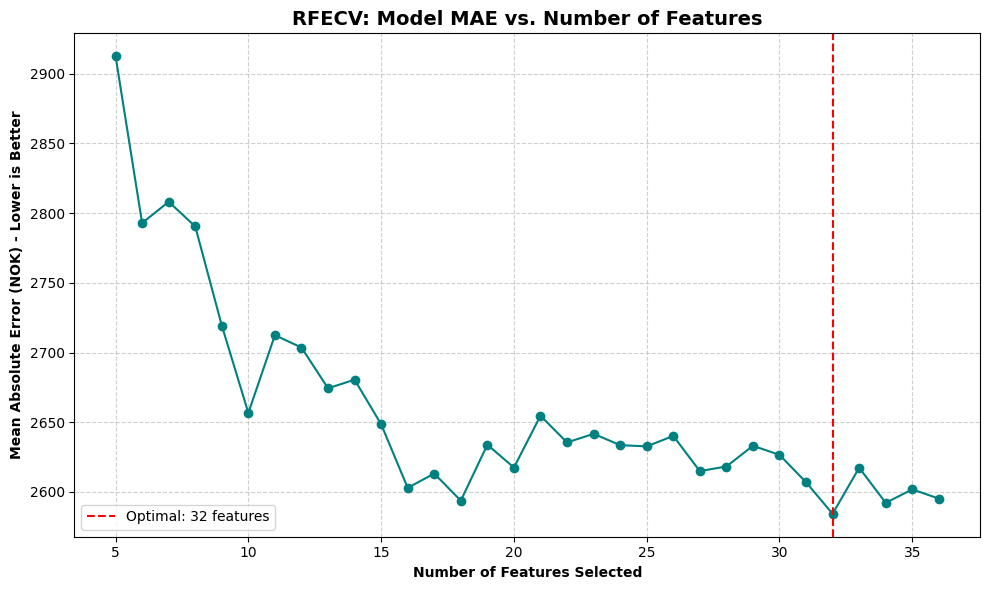

In [23]:
# 6. Plot the CV score vs. number of features
plt.figure(figsize=(10, 6))
plt.title('RFECV: Model MAE vs. Number of Features', fontsize=14, fontweight='bold')
plt.xlabel('Number of Features Selected', fontweight='bold')
plt.ylabel('Mean Absolute Error (NOK) - Lower is Better', fontweight='bold')

# Multiply by -1 to convert 'neg_mean_absolute_error' back to normal MAE for readability
mae_scores = -1 * selector.cv_results_['mean_test_score']

# Plot the scores
plt.plot(range(5, 5 + len(mae_scores)), mae_scores, marker='o', color='teal') # min features is 5 as set in RFECV

plt.axvline(x=optimal_num_features, color='red', linestyle='--', label=f'Optimal: {optimal_num_features} features')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 7. (Optional) Create your final cleaned datasets
# X_train_optimized = X_train_f[selected_features]
# X_test_optimized = X_test_f[selected_features]

In [24]:
X_train_rfe = X_train.drop(columns=rfe_dropped_features)
X_test_rfe = X_test.drop(columns=rfe_dropped_features)

In [25]:
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

# Train folf
lgbm_model.fit(X_train_rfe, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train_rfe)), 0, None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")

# Test fold
sfs_model_pred = np.clip(np.array(lgbm_model.predict(X_test_rfe)), 0, None)

baseline_mae = mean_absolute_error(y_test, sfs_model_pred)
print("Baseline MAE:", baseline_mae)

MAE on training fold: 342.27 NOK
Baseline MAE: 2637.8515900322495


**Sequential Forward Selection**

In [26]:
from sklearn.feature_selection import SequentialFeatureSelector
import matplotlib.pyplot as plt

# Assuming lgbm_base, X_combined, y_combined, and ps are already defined from your previous code

print("Starting Sequential Forward Selection...")
# SFS requires you to specify how many features you want to find, 
# or you can set it to 'auto' to let it stop when performance stops improving.
sfs = SequentialFeatureSelector(
    estimator=lgbm_base,
    n_features_to_select='auto', # Let the algorithm decide the best stopping point
    direction='forward',         # <--- Start at 0 and build up
    cv=PredefinedSplit(test_fold), # Use Hold-Out split
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

# Fit SFS
sfs.fit(X_combined, y_combined)

# Extract selected features
sfs_selected_features = X_combined.columns[sfs.support_].tolist()
sfs_dropped_features = X_combined.columns[~sfs.support_].tolist()

print(f"\nForward Selection kept {len(sfs_selected_features)} features.")
print(f"Features kept: {sfs_selected_features}")
print(f"\nFeatures ignored: {sfs_dropped_features}")

Starting Sequential Forward Selection...

Forward Selection kept 18 features.
Features kept: ['recency', 'monetary', 'avg_revenue', 'weighted_rev', 'monetary_x_frequency', 'tenure_days', 'revenue_per_day', 'rentals_per_day', 'n_summer', 'active_months', 'revenue_trend', 'pct_weekly_rentals', 'cluster_affinity_0', 'cluster_affinity_1', 'cluster_affinity_2', 'cluster_affinity_7', 'max_retail_price', 'avg_price_per_week']

Features ignored: ['frequency', 'std_revenue', 'avg_duration', 'recency_x_monetary', 'recency_x_frequency', 'avg_days_between_rentals', 'recency_ratio', 'n_spring', 'n_autumn', 'n_winter', 'cluster_affinity_3', 'cluster_affinity_4', 'cluster_affinity_5', 'cluster_affinity_6', 'n_clusters_rented', 'style_entropy', 'avg_retail_price', 'weighted_frequency']


In [27]:
X_train_sfs = X_train.drop(columns=sfs_dropped_features)
X_test_sfs = X_test.drop(columns=sfs_dropped_features)

In [28]:
lgbm_model = lgb.LGBMRegressor(
    n_estimators      = 500,
    learning_rate     = 0.05,
    max_depth         = 6,
    min_child_samples = 20,
    subsample         = 0.8,
    random_state      = 42,
    verbose           = -1,

    objective="tweedie",
    tweedie_variance_power=1.3
)

# Train fold
lgbm_model.fit(X_train_sfs, y_train)

train_predictions = np.clip(np.array(lgbm_model.predict(X_train_sfs)), 0, None)
train_mae = mean_absolute_error(y_train, train_predictions)
print(f"MAE on training fold: {train_mae:.2f} NOK")


# Test fold
sfs_model_pred = np.clip(np.array(lgbm_model.predict(X_test_sfs)), 0, None)

baseline_mae = mean_absolute_error(y_test, sfs_model_pred)
print("Baseline MAE:", baseline_mae)

MAE on training fold: 377.46 NOK
Baseline MAE: 2499.4120051299424


## Sequential Feature Selection for 2 Stage Model 

**Regression LightGBM for customers spending more than 0**

In [29]:
# 1. Daten isolieren: Nur die AKTIVEN Kunden aus dem Training Set holen
active_mask_train = (y_train > 0).values.ravel()

X_train_active = X_train[active_mask_train]
y_train_active = y_train.values.ravel()[active_mask_train]

print(f"Starte Feature Selection auf {len(y_train_active)} aktiven Kunden...")

# 2. Das Basis-Modell für die Selection definieren
# Wir nehmen weniger Bäume (100) als im finalen Modell, damit die SFS nicht ewig dauert.
# Wichtig: objective='mae', damit Ausreißer die Feature-Wahl nicht verzerren!
regressor_for_sfs = lgb.LGBMRegressor(
    objective='mae',
    n_estimators=100, 
    random_state=42,
    verbose=-1
)

# 3. Sequential Forward Selection konfigurieren
sfs = SequentialFeatureSelector(
    estimator=regressor_for_sfs,
    n_features_to_select='auto',        # 'auto' wählt die beste Anzahl, alternativ eine feste Zahl (z.B. 10) eintragen
    tol=1e-3,                           # Stoppt, wenn ein neues Feature den MAE nicht um mindestens diesen Wert verbessert
    direction='forward',
    scoring='neg_mean_absolute_error',  # Wir optimieren knallhart auf MAE
    cv=PredefinedSplit(test_fold),                               # 5-Fold Cross Validation
    n_jobs=-1                           # Nutzt alle CPU-Kerne für maximale Geschwindigkeit
)

# 4. SFS trainieren (das kann je nach Anzahl der Features ein paar Minuten dauern)
sfs.fit(X_train_active, y_train_active)

# 5. Die Gewinner-Features extrahieren
selected_features_stage2 = X_train.columns[sfs.get_support()]

print("\n=== SFS Abgeschlossen ===")
print(f"Es wurden {len(selected_features_stage2)} Features für Stage 2 (Revenue) ausgewählt:\n")
for i, feature in enumerate(selected_features_stage2, 1):
    print(f"{i}. {feature}")

# 6. Neue, gefilterte DataFrames für dein Stage 2 Modell erstellen
X_train_f_stage2 = X_train[selected_features_stage2]
X_test_f_stage2  = X_test[selected_features_stage2]

Starte Feature Selection auf 439 aktiven Kunden...


IndexError: index 439 is out of bounds for axis 0 with size 439

**Customer churn prediction model**

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb
import numpy as np

# 1. Zielvariable binarisieren (falls noch nicht geschehen)
y_train_churn = (y_train > 0).astype(int).values.ravel()

print(f"Starte Feature Selection auf dem gesamten Training Set ({len(y_train_churn)} Kunden)...")

# 2. Das Basis-Modell für den Classifier definieren
# Wir nutzen scale_pos_weight, damit das Modell die wenigen aktiven Kunden ernst nimmt
n_inactive_sfs = (y_train_churn == 0).sum()
n_active_sfs   = (y_train_churn == 1).sum()

classifier_for_sfs = lgb.LGBMClassifier(
    n_estimators=100, 
    scale_pos_weight=n_inactive_sfs / n_active_sfs,
    random_state=42,
    verbose=-1
)

# 3. Stratified K-Fold für unbalancierte Daten
# Sorgt dafür, dass in jedem Fold das Verhältnis von 12.5:1 erhalten bleibt
# cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Sequential Forward Selection konfigurieren
sfs_classifier = SequentialFeatureSelector(
    estimator=classifier_for_sfs,
    n_features_to_select='auto', 
    tol=1e-4,                           
    direction='forward',
    scoring='roc_auc',                  # Optimiert auf die Trennschärfe zwischen 0 und 1
    cv=TimeSeriesSplit(n_splits=3),                   
    n_jobs=-1                           
)

# 5. SFS trainieren (auf ALL_DATA)
sfs_classifier.fit(X_train, y_train_churn)

# 6. Die Gewinner-Features extrahieren
selected_features_stage1 = X_train.columns[sfs_classifier.get_support()]

print("\n=== SFS Classifier Abgeschlossen ===")
print(f"Es wurden {len(selected_features_stage1)} Features für Stage 1 (Churn) ausgewählt:\n")
for i, feature in enumerate(selected_features_stage1, 1):
    print(f"{i}. {feature}")

# 7. Neue, gefilterte DataFrames für dein Stage 1 Modell erstellen
X_train_f_stage1 = X_train[selected_features_stage1]
X_test_f_stage1  = X_test[selected_features_stage1]

Starte Feature Selection auf dem gesamten Training Set (5943 Kunden)...

=== SFS Classifier Abgeschlossen ===
Es wurden 4 Features für Stage 1 (Churn) ausgewählt:

1. recency
2. monetary_x_frequency
3. pct_weekly_rentals
4. cluster_affinity_6
